# Comparativa global de modelos

Este notebook unifica la comparativa final de todos los modelos del TFG:

- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Linear SVM
- TensorFlow MLP
- LSTM
- CNN-1D

Se sigue la misma idea de `comparativaArboles.ipynb`: entrenar cada ganador con todo el conjunto de train, medir la inferencia y comparar:

- `Latencia_ms`
- `Thruput (paq/s)`
- `Núcleos CPU`
- `Pico RAM (MB)`
- `Porcentaje CPU`

Además se genera:

- una curva ROC conjunta de todos los modelos
- un panel de matrices de confusión

Nota metodológica: los modelos secuenciales (`LSTM` y `CNN-1D`) se evalúan sobre su conjunto efectivo de secuencias, por lo que el número de muestras evaluadas es ligeramente menor que en los modelos tabulares.

In [1]:
import os
import time
import numpy as np
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

I0000 00:00:1775903895.543508 2110564 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775903899.850484 2110564 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775903907.590690 2110564 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Diccionario de Métricas de Evaluación

| Métrica | ¿Qué es y qué representa? (Significado Técnico) | ¿Cómo la hemos calculado? (Metodología de Código) |
| :--- | :--- | :--- |
| **F1-Score** | Métrica de eficacia predictiva. Es la media armónica entre Precisión y Sensibilidad (Recall). Representa la capacidad del modelo para detectar ataques reales minimizando las falsas alarmas, siendo la métrica ideal para tráfico de red desbalanceado. | Calculada mediante la librería `scikit-learn` (`f1_score`), cruzando las etiquetas reales del dataset de test frente a las predicciones generadas por el modelo. |
| **Latencia (ms)** | Tiempo de respuesta unitario. Representa los milisegundos físicos que tarda el sistema en procesar y clasificar un único paquete de red desde que entra al modelo hasta que sale el veredicto. | Calculada midiendo el tiempo real transcurrido (*Wall Time* mediante `time.perf_counter()`) al procesar el set de test por lotes, dividido entre el número total de paquetes procesados. |
| **Throughput (paq/s)** | Caudal o ancho de banda de procesamiento. Representa el volumen de tráfico (paquetes por segundo) que el modelo puede soportar sin generar cuellos de botella en la red. | Obtenido matemáticamente dividiendo el número total de paquetes del conjunto de test entre el tiempo físico total (*Wall Time* en segundos) que tardó en procesarlos. |
| **Núcleos CPU** | Nivel de concurrencia y paralelismo. Representa la cantidad de hilos de ejecución (*threads*) simultáneos que el modelo ha instanciado a nivel de sistema operativo para resolver la inferencia. | Calculado dividiendo el Tiempo Total de CPU (tiempo de trabajo sumado de todos los hilos, obtenido vía `psutil`) entre el tiempo físico real transcurrido (*Wall Time*). |
| **Pico RAM (MB)** | Huella máxima de memoria volátil (*Resident Set Size*). Representa la cantidad de memoria física extra que el sistema operativo tuvo que ceder al proceso para instanciar matrices o tensores durante la predicción. | Monitorizando el proceso con `psutil.memory_info().rss`, restando la memoria base (antes del bucle de inferencia) al pico máximo de memoria alcanzado durante el procesamiento de los lotes. |
| **Porcentaje CPU** | Carga computacional global. Representa qué porcentaje de la capacidad total del hardware del servidor está siendo "secuestrada" por el Sistema de Detección de Intrusiones. | Calculado dividiendo los "Núcleos CPU" utilizados por el modelo entre el número total de hilos lógicos de hardware disponibles en el servidor de pruebas. |


En nuestro benchmark no estamos midiendo el entrenamiento, sino la inferencia. Durante el entrenamiento, casi todos los modelos sí intentan usar el 100% de los núcleos porque están construyendo matemáticas complejas desde cero. Pero en la inferencia, el modelo ya está construido; solo tiene que pasar los datos por la fórmula.




In [ ]:
# Configuración de visualización

sns.set_style("whitegrid")

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
TRAIN_DEVICE = "/GPU:0" if HAS_GPU else "/CPU:0"
INFER_DEVICE = "/CPU:0"

if HAS_GPU:
    print("GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.")
else:
    print("No hay GPU disponible. Todo el notebook se ejecutará en CPU.")

tf.keras.backend.clear_session()

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps + 1):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps - 1])
    return np.array(Xs), np.array(ys)

def build_mlp_model(input_dim):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        keras.layers.Dense(96, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_lstm_model(time_steps, n_features, units, num_layers):
    model = Sequential()
    model.add(Input(shape=(time_steps, n_features)))
    if num_layers == 1:
        model.add(LSTM(units, unroll=True))
    else:
        model.add(LSTM(units, return_sequences=True, unroll=True))
        model.add(Dropout(0.2))
        model.add(LSTM(units, unroll=True))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

DEFAULT_CNN_DROPOUT = 0.2

def build_cnn1d_model(time_steps, n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_CNN_DROPOUT):
    model = keras.Sequential([
        keras.layers.Input(shape=(time_steps, n_features)),
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def clone_keras_model_to_cpu(builder_fn, trained_model, *builder_args):
    with tf.device(INFER_DEVICE):
        cpu_model = builder_fn(*builder_args)
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

def benchmark_predict(predict_fn, X_eval, model_name, block_size=2048, warmup_size=1000, repetitions=3):
    if len(X_eval) == 0:
        raise ValueError(f"{model_name}: no hay muestras para benchmark.")

    proceso = psutil.Process(os.getpid())
    warmup = X_eval[:min(warmup_size, len(X_eval))]
    _ = predict_fn(warmup)

    tiempos_muro = []
    tiempos_cpu = []
    picos_ram = []

    for _ in range(repetitions):
        cpu_ini = proceso.cpu_times() # Medición de hilo de CPU antes de la inferencia
        ram_base = proceso.memory_info().rss / (1024 * 1024)
        pico_ram_rep = ram_base

        t0 = time.perf_counter()
        for inicio in range(0, len(X_eval), block_size):
            fin = inicio + block_size
            bloque = X_eval[inicio:fin]
            _ = predict_fn(bloque)

            ram_actual = proceso.memory_info().rss / (1024 * 1024)
            if ram_actual > pico_ram_rep:
                pico_ram_rep = ram_actual

        t1 = time.perf_counter()
        cpu_fin = proceso.cpu_times() # Medición de hilo de CPU después de la inferencia

        tiempos_muro.append(t1 - t0)
        # Usamos tiempo de user y tiempo de system ya que el tiempo de user refleja el tiempo de CPU consumido por el proceso, mientras que el tiempo de system refleja el tiempo que el sistema operativo ha dedicado a ejecutar tareas en nombre del proceso, como la gestión de memoria o la entrada/salida. Al sumar ambos tiempos, obtenemos una medida más completa del consumo de CPU del proceso durante la inferencia.
        tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system)) 
        picos_ram.append(pico_ram_rep - ram_base)

    media_muro = float(np.mean(tiempos_muro))
    media_cpu = float(np.mean(tiempos_cpu))
    pico_max_ram = float(np.max(picos_ram))
    total_nucleos = psutil.cpu_count(logical=True)

    return {
        "Modelo": model_name,
        "Latencia_ms": round((media_muro / len(X_eval)) * 1000, 5),
        "Thruput (paq/s)": round(len(X_eval) / media_muro, 0),
        "CPU efectiva (núcleos eq.)": round(media_cpu / media_muro if media_muro > 0 else 1, 1),
        "Pico RAM (MB)": round(pico_max_ram, 2),
        "CPU efectiva (%)": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
    }

def register_outputs(container_benchmark, container_roc, container_cm, benchmark_row, model_name, y_true, y_pred, y_score):
    benchmark_row = dict(benchmark_row)
    benchmark_row["F1_macro"] = round(float(f1_score(y_true, y_pred, average="macro")), 4)
    container_benchmark.append(benchmark_row)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    container_roc.append({"Modelo": model_name, "fpr": fpr, "tpr": tpr, "auc": roc_auc})
    container_cm.append({"Modelo": model_name, "cm": confusion_matrix(y_true, y_pred)})
    print(f"  -> {model_name}: F1={benchmark_row['F1_macro']:.4f} | AUC={roc_auc:.4f} | Acc={accuracy_score(y_true, y_pred):.4f}")


GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.


Analogía del Restaurante

Imagina que vas a un restaurante y quieres saber el tiempo total que han trabajado para ti para preparar tu plato:

    Tiempo user: Es el tiempo que el cocinero (tu modelo de Machine Learning) pasa cortando verduras y cocinando la carne.

    Tiempo system: Es el tiempo que el camarero (el Sistema Operativo) pasa yendo a la despensa a buscar ingredientes (pedir RAM) y llevándote el plato a la mesa.

La fórmula completa:
(Tiempo del Cocinero final - Tiempo del Cocinero inicial) + (Tiempo del Camarero final - Tiempo del Camarero inicial)

In [3]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"
TARGET_COL = "attack_cat"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy()
X_test_np = x_test.to_numpy()
y_full_train = y_train.to_numpy()
y_test_np = y_test.to_numpy()

y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

print(f"Train: {X_full_train.shape} | Test: {X_test_np.shape}")
print("Tras convertir -1/1 a 0/1, la clase 0 corresponde a Ataque y la clase 1 a Normal.")

# ==========================================
# 2. CONFIGURACIÓN DE LOS GANADORES
# ==========================================

# Árboles: se respetan los modelos usados en comparativaArboles.ipynb
RF_CONFIG = {"n_estimators": 50, "max_depth": 23}
XGB_CONFIG = {"n_estimators": 200, "max_depth": 11, "learning_rate": 0.1}
LGBM_CONFIG = {"n_estimators": 100, "num_leaves": 145, "max_depth": 12, "learning_rate": 0.1}
CATBOOST_CONFIG = {"iterations": 500, "depth": 10, "learning_rate": 0.1}

# Modelos individuales: se respetan los ganadores usados en las celdas finales de benchmark/ROC
SVM_C = 0.000187
MLP_INPUT_DIM = X_full_train.shape[1]
LSTM_CONFIG = {"ts": 10, "u": 32, "l": 1}
CNN1D_CONFIG = {"ts": 15, "nf": 96, "k": 3, "d": 32}


Train: (175341, 12) | Test: (82332, 12)
Tras convertir -1/1 a 0/1, la clase 0 corresponde a Ataque y la clase 1 a Normal.


In [4]:
# ==========================================
# 3. ENTRENAMIENTO, BENCHMARK Y MÉTRICAS
# ==========================================

benchmark_rows = []
roc_payloads = []
cm_payloads = []

X_test_np_arr = np.array(X_test_np)

print("Entrenando y evaluando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_full_train, y_full_train_01)
rf_predict = lambda X: np.asarray(rf_model.predict(X)).astype(np.int8).ravel()
rf_score = lambda X: rf_model.predict_proba(X)[:, 1]
rf_benchmark = benchmark_predict(rf_predict, X_test_np_arr, "Random Forest", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, rf_benchmark, "Random Forest", y_test_np01, rf_predict(X_test_np_arr), rf_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=XGB_CONFIG["n_estimators"],
    max_depth=XGB_CONFIG["max_depth"],
    learning_rate=XGB_CONFIG["learning_rate"],
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_full_train, y_full_train_01)
xgb_model.set_params(device="cpu")
xgb_predict = lambda X: np.asarray(xgb_model.predict(X)).astype(np.int8).ravel()
xgb_score = lambda X: xgb_model.predict_proba(X)[:, 1]
xgb_benchmark = benchmark_predict(xgb_predict, X_test_np_arr, "XGBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, xgb_benchmark, "XGBoost", y_test_np01, xgb_predict(X_test_np_arr), xgb_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=LGBM_CONFIG["n_estimators"],
    num_leaves=LGBM_CONFIG["num_leaves"],
    max_depth=LGBM_CONFIG["max_depth"],
    learning_rate=LGBM_CONFIG["learning_rate"],
    device_type="gpu" if HAS_GPU else "cpu",
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_full_train, y_full_train_01)
lgbm_model.set_params(device_type="cpu")
lgbm_predict = lambda X: np.asarray(lgbm_model.predict(X)).astype(np.int8).ravel()
lgbm_score = lambda X: lgbm_model.predict_proba(X)[:, 1]
lgbm_benchmark = benchmark_predict(lgbm_predict, X_test_np_arr, "LightGBM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, lgbm_benchmark, "LightGBM", y_test_np01, lgbm_predict(X_test_np_arr), lgbm_score(X_test_np_arr))

# ==========================================
print("\nEntrenando y evaluando CatBoost...")
cat_model = CatBoostClassifier(
    iterations=CATBOOST_CONFIG["iterations"],
    depth=CATBOOST_CONFIG["depth"],
    learning_rate=CATBOOST_CONFIG["learning_rate"],
    random_seed=42,
    logging_level="Silent",
    task_type="GPU" if HAS_GPU else "CPU"
)
cat_model.fit(X_full_train, y_full_train_01)
cat_predict = lambda X: np.asarray(cat_model.predict(X, task_type="CPU")).astype(np.int8).ravel()
cat_score = lambda X: cat_model.predict_proba(X, task_type="CPU")[:, 1]
cat_benchmark = benchmark_predict(cat_predict, X_test_np_arr, "CatBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cat_benchmark, "CatBoost", y_test_np01, cat_predict(X_test_np_arr), cat_score(X_test_np_arr))

Entrenando y evaluando Random Forest...
  -> Random Forest: F1=0.8606 | AUC=0.9742 | Acc=0.8665

Entrenando y evaluando XGBoost...
  -> XGBoost: F1=0.8579 | AUC=0.9777 | Acc=0.8641

Entrenando y evaluando LightGBM...


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

  -> LightGBM: F1=0.8607 | AUC=0.9793 | Acc=0.8668

Entrenando y evaluando CatBoost...
  -> CatBoost: F1=0.8570 | AUC=0.9771 | Acc=0.8634


In [5]:
# ==========================================

print("\nEntrenando y evaluando Linear SVM...")
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=SVM_C, dual=False, random_state=42, max_iter=2000)
)
svm_model.fit(X_full_train, y_full_train_01)
svm_predict = lambda X: np.asarray(svm_model.predict(X)).astype(np.int8).ravel()
svm_score = lambda X: svm_model.decision_function(X)
svm_benchmark = benchmark_predict(svm_predict, X_test_np_arr, "Linear SVM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, svm_benchmark, "Linear SVM", y_test_np01, svm_predict(X_test_np_arr), svm_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando TensorFlow MLP...")
tf.keras.backend.clear_session()
mlp_scaler = StandardScaler()
X_train_scaled_mlp = mlp_scaler.fit_transform(X_full_train)
X_test_scaled_mlp = mlp_scaler.transform(X_test_np_arr)
with tf.device(TRAIN_DEVICE):
    mlp_model = build_mlp_model(MLP_INPUT_DIM)
    mlp_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    mlp_model.fit(
        X_train_scaled_mlp,
        y_full_train_01,
        validation_split=0.1,
        epochs=40,
        batch_size=2048,
        callbacks=[mlp_early],
        verbose=0
    )
mlp_model_cpu = clone_keras_model_to_cpu(build_mlp_model, mlp_model, MLP_INPUT_DIM)
def mlp_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def mlp_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
mlp_benchmark = benchmark_predict(mlp_predict_labels, X_test_scaled_mlp, "TensorFlow MLP", block_size=4096, warmup_size=1024)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, mlp_benchmark, "TensorFlow MLP", y_test_np01, mlp_predict_labels(X_test_scaled_mlp), mlp_predict_scores(X_test_scaled_mlp))

# ==========================================

print("\nEntrenando y evaluando LSTM...")
tf.keras.backend.clear_session()
lstm_scaler = StandardScaler()
X_train_scaled_lstm = lstm_scaler.fit_transform(X_full_train)
X_test_scaled_lstm = lstm_scaler.transform(X_test_np_arr)
X_train_seq_lstm, y_train_seq_lstm = create_sequences(X_train_scaled_lstm, y_full_train_01, LSTM_CONFIG["ts"])
X_test_seq_lstm, y_test_seq_lstm = create_sequences(X_test_scaled_lstm, y_test_np01, LSTM_CONFIG["ts"])
with tf.device(TRAIN_DEVICE):
    lstm_model = build_lstm_model(LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
    lstm_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    lstm_model.fit(
        X_train_seq_lstm,
        y_train_seq_lstm,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[lstm_early],
        verbose=0
    )
lstm_model_cpu = clone_keras_model_to_cpu(build_lstm_model, lstm_model, LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
def lstm_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def lstm_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
lstm_benchmark = benchmark_predict(lstm_predict_labels, X_test_seq_lstm, "LSTM", block_size=2048, warmup_size=512)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, lstm_benchmark, "LSTM", y_test_seq_lstm, lstm_predict_labels(X_test_seq_lstm), lstm_predict_scores(X_test_seq_lstm))

# ==========================================

print("\nEntrenando y evaluando CNN-1D...")
tf.keras.backend.clear_session()
cnn_scaler = StandardScaler()
X_train_scaled_cnn = cnn_scaler.fit_transform(X_full_train)
X_test_scaled_cnn = cnn_scaler.transform(X_test_np_arr)
X_train_seq_cnn, y_train_seq_cnn = create_sequences(X_train_scaled_cnn, y_full_train_01, CNN1D_CONFIG["ts"])
X_test_seq_cnn, y_test_seq_cnn = create_sequences(X_test_scaled_cnn, y_test_np01, CNN1D_CONFIG["ts"])
with tf.device(TRAIN_DEVICE):
    cnn_model = build_cnn1d_model(CNN1D_CONFIG["ts"], X_train_seq_cnn.shape[2], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
    cnn_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cnn_model.fit(
        X_train_seq_cnn,
        y_train_seq_cnn,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[cnn_early],
        verbose=0
    )
cnn_model_cpu = clone_keras_model_to_cpu(build_cnn1d_model, cnn_model, CNN1D_CONFIG["ts"], X_train_seq_cnn.shape[2], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
def cnn_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def cnn_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
cnn_benchmark = benchmark_predict(cnn_predict_labels, X_test_seq_cnn, "CNN-1D", block_size=2048, warmup_size=512)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cnn_benchmark, "CNN-1D", y_test_seq_cnn, cnn_predict_labels(X_test_seq_cnn), cnn_predict_scores(X_test_seq_cnn))



Entrenando y evaluando Linear SVM...
  -> Linear SVM: F1=0.7092 | AUC=0.7492 | Acc=0.7361

Entrenando y evaluando TensorFlow MLP...


I0000 00:00:1775903989.192260 2110564 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43415 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1775903989.202934 2110564 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43485 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1775903989.212340 2110564 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43485 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1775903989.222456 2110564 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43485 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.

  -> TensorFlow MLP: F1=0.7452 | AUC=0.8981 | Acc=0.7700

Entrenando y evaluando LSTM...


I0000 00:00:1775904013.485764 2139688 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11159__.16
I0000 00:00:1775904013.630654 2139688 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775904014.077908 2139688 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775904014.369380 2139688 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775904018.16510

  -> LSTM: F1=0.9083 | AUC=0.9750 | Acc=0.9114

Entrenando y evaluando CNN-1D...


I0000 00:00:1775904042.837447 2139688 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27480__.21
I0000 00:00:1775904042.886977 2139688 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775904043.161902 2184150 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 36 bytes spill stores, 36 bytes spill loads

I0000 00:00:1775904052.757584 2184089 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_compare_transpose_fusion', 68 bytes spill stores, 68 bytes spill loads

I0000 00:00:1775904054.957953 2139688 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27480__.21
I0000 00:00:1775904055.004897 2139688 dot_search

  -> CNN-1D: F1=0.9355 | AUC=0.9860 | Acc=0.9371



                TABLA GLOBAL DE RENDIMIENTO Y F1
shape: (8, 7)
┌───────────────────┬─────────────┬────────────┬──────────┬──────────┬──────────────────┬──────────┐
│ Modelo            ┆ Latencia_ms ┆ Thruput    ┆ CPU      ┆ Pico RAM ┆ CPU efectiva (%) ┆ F1_macro │
│ ---               ┆ ---         ┆ (paq/s)    ┆ efectiva ┆ (MB)     ┆ ---              ┆ ---      │
│ str               ┆ f64         ┆ ---        ┆ (núcleos ┆ ---      ┆ f64              ┆ f64      │
│                   ┆             ┆ f64        ┆ eq.)     ┆ f64      ┆                  ┆          │
│                   ┆             ┆            ┆ ---      ┆          ┆                  ┆          │
│                   ┆             ┆            ┆ f64      ┆          ┆                  ┆          │
╞═══════════════════╪═════════════╪════════════╪══════════╪══════════╪══════════════════╪══════════╡
│ Linear SVM        ┆ 0.00014     ┆ 7.297614e6 ┆ 0.9      ┆ 0.0      ┆ 0.9              ┆ 0.7092   │
│ XGBoost           ┆ 0.000

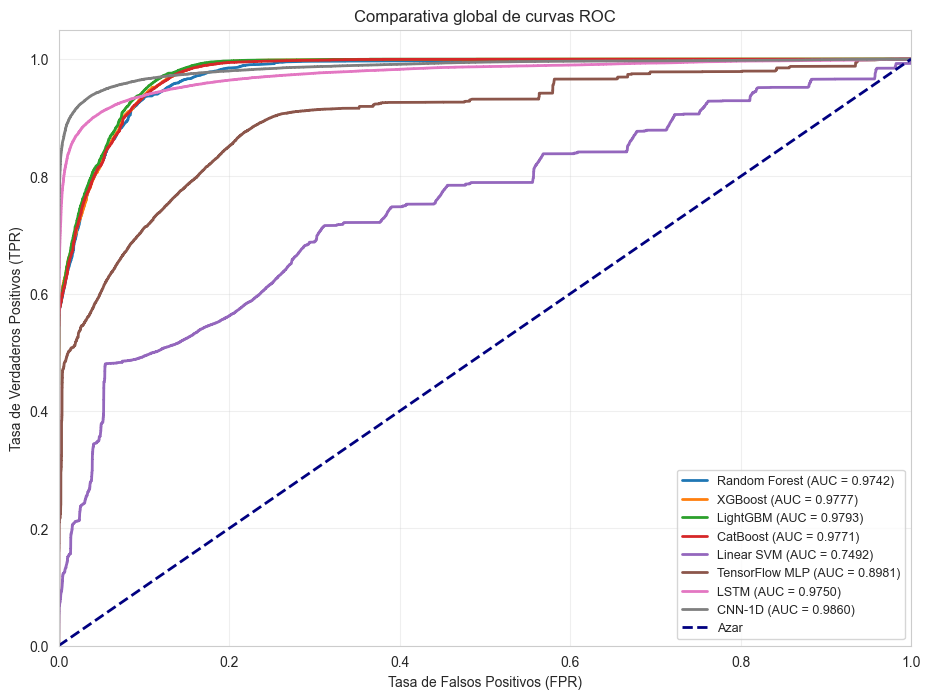

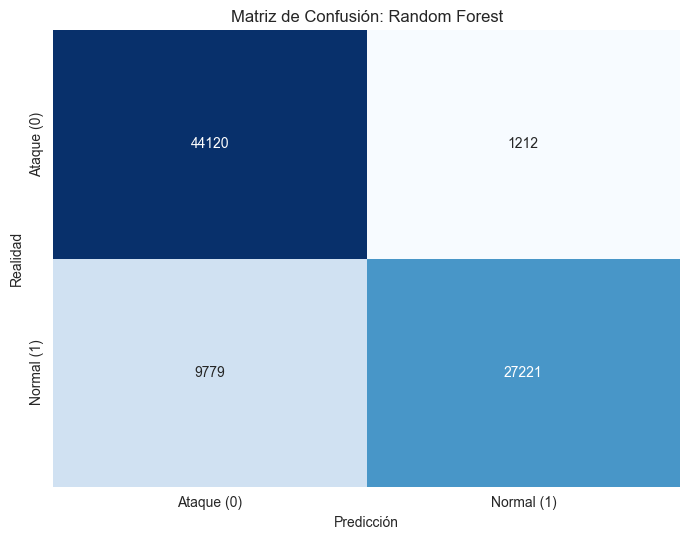

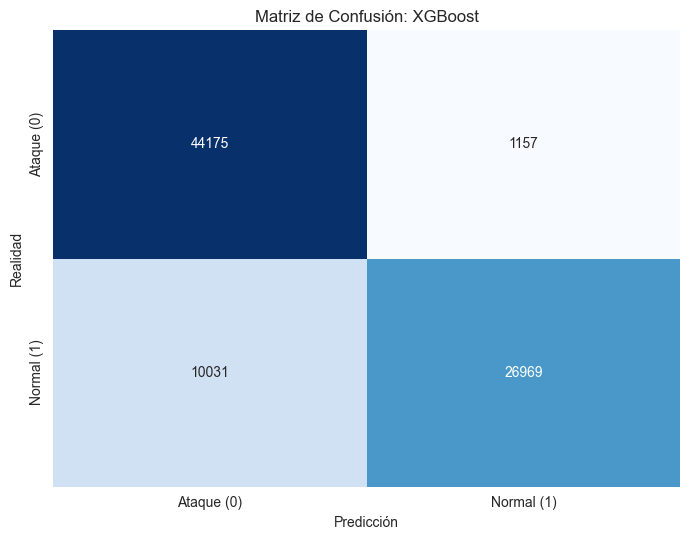

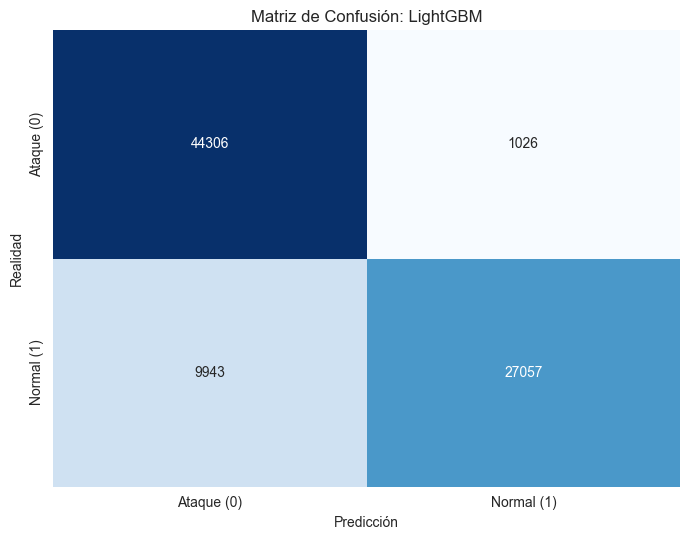

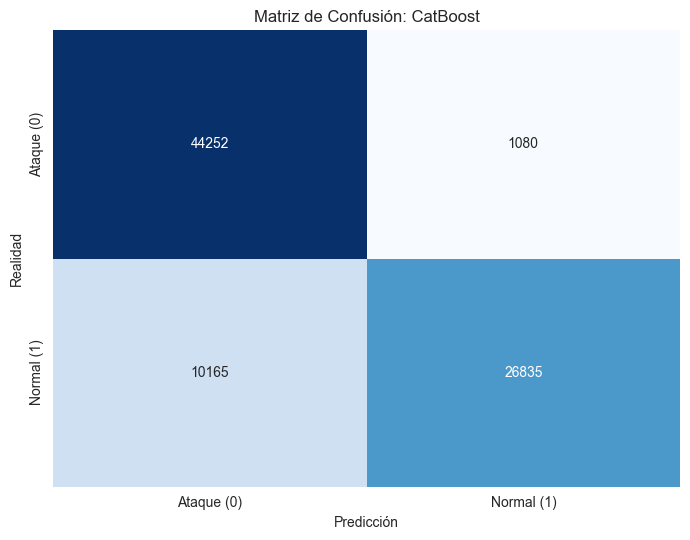

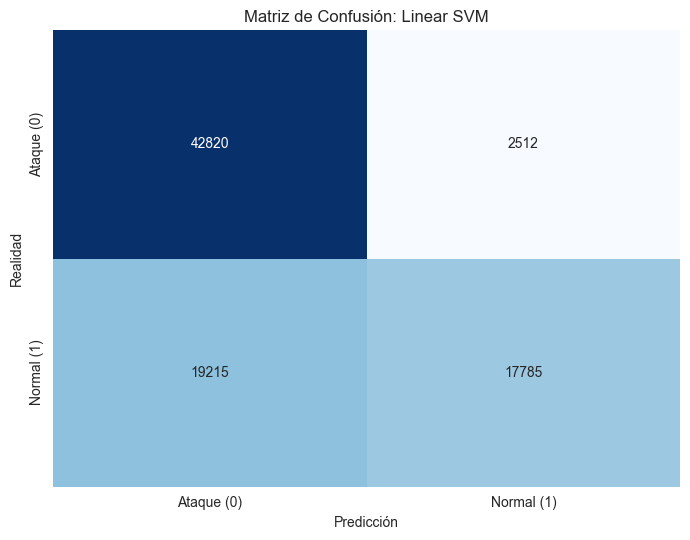

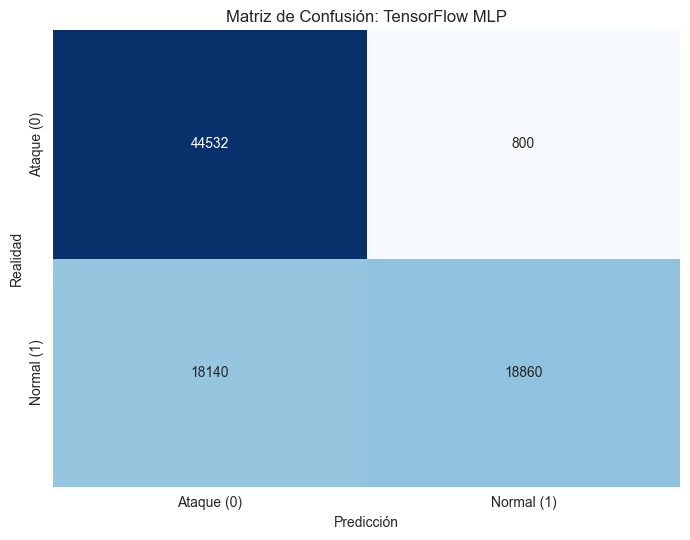

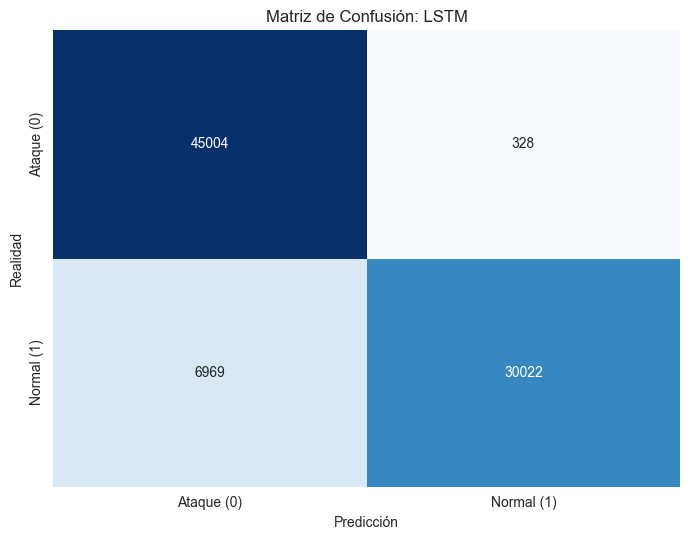

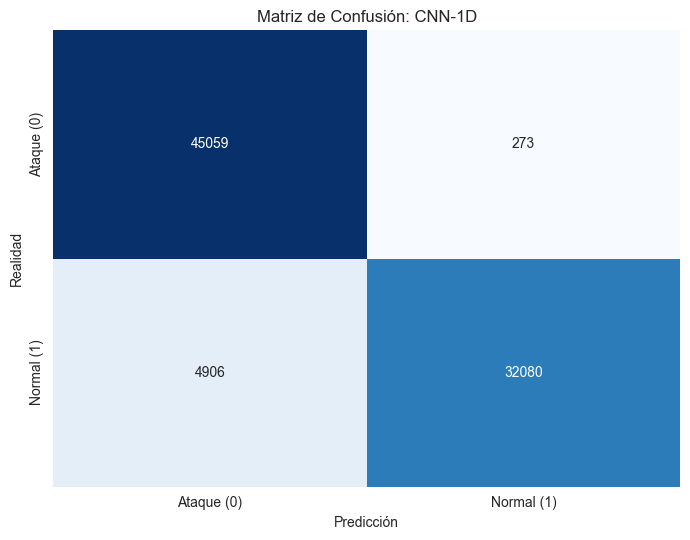

In [6]:

df_benchmark = pl.DataFrame(benchmark_rows).sort("Latencia_ms")
print("\n" + "=" * 95)
print("                TABLA GLOBAL DE RENDIMIENTO Y F1")
print("=" * 95)
print(df_benchmark)

plt.figure(figsize=(11, 8))
for payload in roc_payloads:
    plt.plot(payload["fpr"], payload["tpr"], lw=2, label=f"{payload['Modelo']} (AUC = {payload['auc']:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Azar")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Comparativa global de curvas ROC")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

for payload in cm_payloads:
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(
        payload["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Ataque (0)", "Normal (1)"],
        yticklabels=["Ataque (0)", "Normal (1)"]
    )
    ax.set_title(f"Matriz de Confusión: {payload['Modelo']}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Realidad")
    plt.tight_layout()
    plt.show()


